# BloodCell Classifier — Progetto BloodMNIST (Adversarial Training)
**Classificazione di cellule ematiche con CNN, robustezza estrema e spiegabilità visiva**

Questo notebook implementa:
- **Fase 0**: Analisi dell'Agente e dell'Ambiente
- **Fase 1**: Preparazione e analisi del dataset BloodMNIST
- **Fase 2**: Addestramento CNN (ResNet-18) base tramite Grid Search
- **Fase 2b/c**: Attacchi FGSM/PGD e **Adversarial Fine-Tuning** per aumentare drasticamente la robustezza
- **Fase 3**: Valutazione del modello più robusto (Matrici di confusione, curve epsilon)
- **Componente Avanzata**: Grad-CAM per verificare che il modello si concentri sulle reali strutture cellulari e non su artefatti di sfondo.


In [12]:
# Installazione dipendenze
# !pip install medmnist torchcam grad-cam scikit-learn tqdm -q


In [ ]:
# Import librerie
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from typing import Optional

import medmnist
from medmnist import BloodMNIST, INFO

# Riproducibilità
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'MedMNIST versione: {medmnist.__version__}')

# Cartelle di output
import os
MODELS_DIR = '../Modelli'
IMAGES_DIR = '../Immagini'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)


Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
MedMNIST versione: 3.0.2


## Fase 0 — Analisi Agente e Ambiente

### Agente: BloodCell Classifier (Robust version)
| Proprietà | Descrizione |
|-----------|-------------|
| **Tipo** | Agente reattivo basato su modello |
| **Percezioni** | Immagini RGB 28x28 px (ridimensionate a 224) |
| **Azioni** | Output di una distribuzione di probabilità su 8 classi |
| **Obiettivo** | Classificazione accurata e **robusta alle perturbazioni** per supporto diagnostico |
| **Architettura** | ResNet-18 fine-tuned + Adversarial Training |

### Caratteristiche dell'Ambiente (PEAS)
Parzialmente osservabile, Stocastico, Episodico, Statico, Discreto, Singolo agente.


In [14]:
# Fase 1 — Preparazione e Analisi del Dataset
info = INFO['bloodmnist']
print('\nInfo BloodMNIST')
print(f"Task: {info['task']}")
print(f"N. classi: {len(info['label'])}")
print(f"Classi: {info['label']}")

CLASS_NAMES = list(info['label'].values())

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = BloodMNIST(split='train', transform=transform_train, download=True, size=224)
val_dataset   = BloodMNIST(split='val',   transform=transform_test,  download=True, size=224)
test_dataset  = BloodMNIST(split='test',  transform=transform_test,  download=True, size=224)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nDataset caricato: Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')



Info BloodMNIST
Task: multi-class
N. classi: 8
Classi: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Using downloaded and verified file: C:\Users\lmurr\.medmnist\bloodmnist_224.npz
Using downloaded and verified file: C:\Users\lmurr\.medmnist\bloodmnist_224.npz
Using downloaded and verified file: C:\Users\lmurr\.medmnist\bloodmnist_224.npz

Dataset caricato: Train: 11959 | Val: 1712 | Test: 3421


## Fase 2 — Addestramento CNN Standard (Grid Search)
Addestriamo una ResNet-18 sulle immagini pulite per trovare la combinazione migliore di iperparametri. Successivamente la sottoporremo ad *Adversarial Fine-Tuning*.


In [15]:
def build_model(num_classes=8, pretrained=True, dropout=0.3):
    model = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
    for param in model.layer1.parameters(): param.requires_grad = False
    for param in model.layer2.parameters(): param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, num_classes))  # type: ignore[assignment]
    return model

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

# Ricerca (Grid Search)
SEARCH_CONFIGS = [
    {'lr': 1e-4, 'weight_decay': 1e-4, 'dropout': 0.3, 'freeze_epochs': 2},
    {'lr': 3e-4, 'weight_decay': 1e-3, 'dropout': 0.5, 'freeze_epochs': 3},
]

GS_EPOCHS   = 15
GS_PATIENCE = 3

def run_config(cfg, tag):
    m = build_model(dropout=cfg['dropout']).to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = optim.AdamW(filter(lambda p: p.requires_grad, m.parameters()), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=GS_EPOCHS)
    best_acc, best_loss, es_counter = 0.0, float('inf'), 0

    for epoch in range(1, GS_EPOCHS + 1):
        if epoch == cfg['freeze_epochs'] + 1:
            for p in m.layer1.parameters(): p.requires_grad = True
            for p in m.layer2.parameters(): p.requires_grad = True
            opt.add_param_group({'params': list(m.layer1.parameters()) + list(m.layer2.parameters()), 'lr': cfg['lr'] / 10})

        tr_loss, tr_acc = train_one_epoch(m, train_loader, opt, crit)
        vl_loss, vl_acc, _, _ = evaluate(m, val_loader, crit)
        sched.step()

        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(m.state_dict(), os.path.join(MODELS_DIR, 'gs_best.pth'))
        if vl_loss < best_loss:
            best_loss = vl_loss; es_counter = 0
        else:
            es_counter += 1
        
        print(f'  [{tag}] ep {epoch:2d}/{GS_EPOCHS} tr={tr_acc:.4f} vl={vl_acc:.4f}')
        if es_counter >= GS_PATIENCE: break
    return best_acc

gs_results = []
for i, cfg in enumerate(SEARCH_CONFIGS):
    best_acc = run_config(cfg, f'{i+1}/{len(SEARCH_CONFIGS)}')
    gs_results.append({'cfg': cfg, 'best_val_acc': best_acc})

best_result = max(gs_results, key=lambda x: x['best_val_acc'])
BEST_CFG = best_result['cfg']

model = build_model(dropout=BEST_CFG['dropout']).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'gs_best.pth'), map_location=DEVICE))
print(f"\nMiglior Configurazione Trovata: {BEST_CFG}")


  [1/2] ep  1/15 tr=0.9095 vl=0.9755


  [1/2] ep  2/15 tr=0.9809 vl=0.9831


  [1/2] ep  3/15 tr=0.9849 vl=0.9871


  [1/2] ep  4/15 tr=0.9893 vl=0.9877


  [1/2] ep  5/15 tr=0.9923 vl=0.9901


...

  [1/2] ep 15/15 tr=0.9991 vl=0.9924


  [2/2] ep  1/15 tr=0.9270 vl=0.9889


  [2/2] ep  2/15 tr=0.9796 vl=0.9836


  [2/2] ep  3/15 tr=0.9816 vl=0.9801


  [2/2] ep  4/15 tr=0.9887 vl=0.9836

Miglior Configurazione Trovata: {'lr': 0.0001, 'weight_decay': 0.0001, 'dropout': 0.3, 'freeze_epochs': 2}


## Fase 2b — Definizione Attacchi Avversariali e Adversarial Fine-Tuning
Ora definiamo le perturbazioni FGSM e PGD. Addestreremo il modello ad essere immune a queste perturbazioni.


In [16]:
criterion = nn.CrossEntropyLoss()
THAL_CLASSES = {2: 'eritroblasto', 3: 'gr. immaturo', 7: 'piastrina'}

def fgsm_attack(model, images, labels, epsilon, criterion):
    images_adv = images.clone().requires_grad_(True)
    outputs = model(images_adv)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()
    return images_adv.detach() + epsilon * images_adv.grad.sign()

def pgd_attack(model, images, labels, epsilon, alpha, n_steps, criterion):
    images_adv = images.clone() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    images_adv = torch.clamp(images_adv, images.min(), images.max())
    for _ in range(n_steps):
        images_adv.requires_grad_(True)
        outputs = model(images_adv)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = images_adv.grad
        if grad is None:
            raise RuntimeError("Impossibile calcolare il gradiente dell'immagine avversaria.")
        images_adv = images_adv.detach() + alpha * grad.sign()
        delta = torch.clamp(images_adv - images, -epsilon, epsilon)
        images_adv = images + delta
    return images_adv.detach()

def evaluate_adversarial_pgd(model, loader, epsilon, alpha, n_steps, criterion, n_classes=8):
    model.eval()
    correct, total = 0, 0
    per_class_correct = np.zeros(n_classes); per_class_total = np.zeros(n_classes)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        imgs_adv = pgd_attack(model, imgs, labels, epsilon, alpha, n_steps, criterion)
        with torch.no_grad(): outputs = model(imgs_adv)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item(); total += imgs.size(0)
        for c in range(n_classes):
            mask = (labels == c)
            per_class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            per_class_total[c] += mask.sum().item()
    return correct / total, np.divide(per_class_correct, per_class_total, out=np.zeros_like(per_class_correct), where=per_class_total > 0)

def evaluate_adversarial_fgsm(model, loader, epsilon, criterion, n_classes=8):
    model.eval()
    correct, total = 0, 0
    per_class_correct = np.zeros(n_classes); per_class_total = np.zeros(n_classes)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        imgs_adv = fgsm_attack(model, imgs, labels, epsilon, criterion)
        with torch.no_grad(): outputs = model(imgs_adv)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item(); total += imgs.size(0)
        for c in range(n_classes):
            mask = (labels == c)
            per_class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            per_class_total[c] += mask.sum().item()
    return correct / total, np.divide(per_class_correct, per_class_total, out=np.zeros_like(per_class_correct), where=per_class_total > 0)


In [17]:
print('\nInizio Adversarial Fine-Tuning')

def train_one_epoch_adv(model, loader, optimizer, criterion, adv_eps=0.05, adv_alpha=0.0125, adv_steps=5):
    # Training misto: 50% accuratezza pulita, 50% robustezza su PGD
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='  Adv Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.squeeze().long().to(DEVICE)
        
        # Genera perturbazioni on-the-fly in modalità eval
        model.eval()
        imgs_adv = pgd_attack(model, imgs, labels, adv_eps, adv_alpha, adv_steps, criterion)
        model.train()
        
        optimizer.zero_grad()
        outputs_clean = model(imgs)
        outputs_adv = model(imgs_adv)
        
        loss = 0.5 * criterion(outputs_clean, labels) + 0.5 * criterion(outputs_adv, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs_adv.argmax(1) == labels).sum().item() 
        total += imgs.size(0)
    return total_loss / total, correct / total

ADV_EPOCHS = 8
TRAIN_EPS  = 0.05
TRAIN_ALFA = 0.0125
TRAIN_STEP = 5

opt_adv = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)
sched_adv = optim.lr_scheduler.CosineAnnealingLR(opt_adv, T_max=ADV_EPOCHS)
best_adv_acc = 0.0

for epoch in range(1, ADV_EPOCHS + 1):
    tr_loss, tr_adv_acc = train_one_epoch_adv(model, train_loader, opt_adv, criterion, adv_eps=TRAIN_EPS, adv_alpha=TRAIN_ALFA, adv_steps=TRAIN_STEP)
    val_clean_loss, val_clean_acc, _, _ = evaluate(model, val_loader, criterion)
    val_adv_acc, _ = evaluate_adversarial_pgd(model, val_loader, TRAIN_EPS, TRAIN_ALFA, TRAIN_STEP, criterion)
    sched_adv.step()
    
    print(f'Epoca [{epoch}/{ADV_EPOCHS}] | Mix Loss: {tr_loss:.4f} | Val Clean: {val_clean_acc*100:.2f}% | Val Adv (PGD): {val_adv_acc*100:.2f}%')
    
    if val_adv_acc > best_adv_acc:
        best_adv_acc = val_adv_acc
        torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'adv_robust_best.pth'))

print('\nCaricamento del modello avversariale definitivo per la validazione...')
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'adv_robust_best.pth'), map_location=DEVICE))



Inizio Adversarial Fine-Tuning


Epoca [1/8] | Mix Loss: 1.8947 | Val Clean: 93.17% | Val Adv (PGD): 22.02%


Epoca [2/8] | Mix Loss: 0.8896 | Val Clean: 92.00% | Val Adv (PGD): 43.93%


Epoca [3/8] | Mix Loss: 0.6766 | Val Clean: 93.57% | Val Adv (PGD): 52.57%


Epoca [4/8] | Mix Loss: 0.5650 | Val Clean: 94.04% | Val Adv (PGD): 55.20%


Epoca [5/8] | Mix Loss: 0.5071 | Val Clean: 94.33% | Val Adv (PGD): 60.81%


Epoca [6/8] | Mix Loss: 0.4683 | Val Clean: 94.16% | Val Adv (PGD): 63.49%


Epoca [7/8] | Mix Loss: 0.4450 | Val Clean: 95.39% | Val Adv (PGD): 62.21%


Epoca [8/8] | Mix Loss: 0.4390 | Val Clean: 95.79% | Val Adv (PGD): 62.97%

Caricamento del modello avversariale definitivo per la validazione...


<All keys matched successfully>

## Fase 3 — Analisi Risultati (sul Modello Robusto)
Valutiamo come l'Adversarial Training ha "appiattito" la curva di deterioramento.



Valutazione FGSM e PGD vs Epsilon
ε=0.00 → FGSM Acc: 93.63% | PGD Acc: 93.63%
ε=0.01 → FGSM Acc: 87.66% | PGD Acc: 85.79%
ε=0.02 → FGSM Acc: 84.01% | PGD Acc: 76.82%
ε=0.05 → FGSM Acc: 75.83% | PGD Acc: 50.13%
ε=0.10 → FGSM Acc: 68.69% | PGD Acc: 11.49%
ε=0.20 → FGSM Acc: 58.99% | PGD Acc: 0.79%


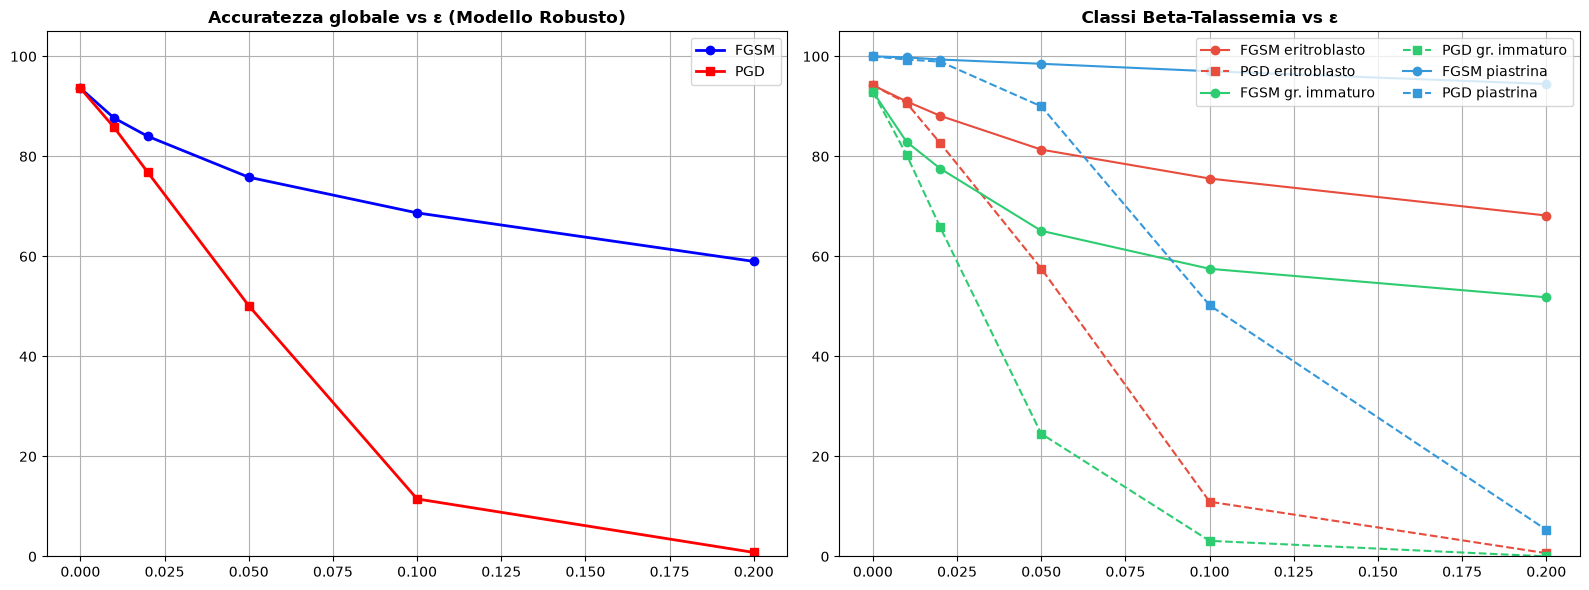

In [18]:
epsilons = [0, 0.01, 0.02, 0.05, 0.1, 0.2]
PGD_STEPS = 10 

fgsm_acc, fgsm_per_class = [], []
pgd_acc, pgd_per_class = [], []

print('\nValutazione FGSM e PGD vs Epsilon')
for eps in epsilons:
    alpha = eps / 4 if eps > 0 else 0.01
    acc_f, per_cls_f = evaluate_adversarial_fgsm(model, test_loader, eps, criterion)
    acc_p, per_cls_p = evaluate_adversarial_pgd(model, test_loader, eps, alpha, PGD_STEPS, criterion)
    
    fgsm_acc.append(acc_f); fgsm_per_class.append(per_cls_f)
    pgd_acc.append(acc_p);  pgd_per_class.append(per_cls_p)
    print(f'ε={eps:.2f} → FGSM Acc: {acc_f*100:.2f}% | PGD Acc: {acc_p*100:.2f}%')

_, clean_acc, clean_preds, clean_labels = evaluate(model, test_loader, criterion)

# Plot Curve Epsilon
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(epsilons, [a*100 for a in fgsm_acc], 'b-o', label='FGSM', lw=2)
axes[0].plot(epsilons, [a*100 for a in pgd_acc], 'r-s', label='PGD', lw=2)
axes[0].set_title('Accuratezza globale vs ε (Modello Robusto)', fontweight='bold')
axes[0].set_ylim(0, 105); axes[0].grid(True); axes[0].legend()

colors_thal = ['#e74c3c', '#2ecc71', '#3498db']
for i, (c, name) in enumerate(THAL_CLASSES.items()):
    axes[1].plot(epsilons, [fgsm_per_class[j][c]*100 for j in range(len(epsilons))], f'-o', color=colors_thal[i], label=f'FGSM {name}')
    axes[1].plot(epsilons, [pgd_per_class[j][c]*100 for j in range(len(epsilons))], f'--s', color=colors_thal[i], label=f'PGD {name}')
axes[1].set_title('Classi Beta-Talassemia vs ε', fontweight='bold')
axes[1].set_ylim(0, 105); axes[1].grid(True); axes[1].legend(ncol=2)
plt.tight_layout()
plt.show()


## Componente Avanzata — Spiegabilità Visiva (Grad-CAM)
Confermiamo visivamente che il modello addestrato avversarialmente basa le sue predizioni sulla **morfologia cellulare al centro** e ignora i pixel di sfondo.

Using downloaded and verified file: C:\Users\lmurr\.medmnist\bloodmnist_224.npz

Avvio dell'analisi Grad-CAM
Raccolti campioni sufficienti per tutte le classi.
Creazione del grafico boxplot...


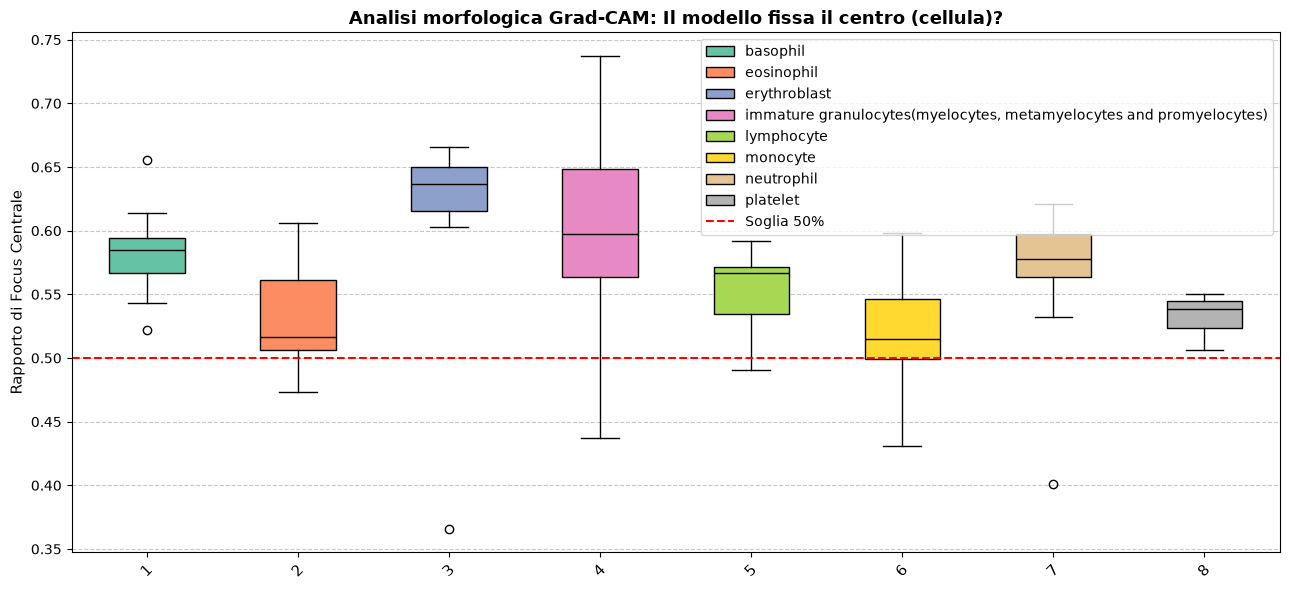

In [ ]:
class GradCAM:
    def __init__(self, model: torch.nn.Module, target_layer: torch.nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        # Estrae il tensore dalla tupla garantita dal full_backward_hook
        self.gradients = grad_output[0]

    def generate(self, input_tensor: torch.Tensor, target_class: Optional[int] = None, size: tuple = (224, 224)) -> tuple:
        self.model.eval()
        
        # Abilita il tracciamento dei gradienti sull'input
        input_tensor.requires_grad_(True)
        
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError("Gradienti o attivazioni non catturati. Controlla il target_layer.")

        # Estrae i tensori puri
        gradients = self.gradients.detach()
        activations = self.activations.detach()

        # Pesi (Global Average Pooling): Media lungo Altezza e Larghezza -> forma (1, C, 1, 1)
        weights = torch.mean(gradients, dim=[2, 3], keepdim=True)

        # Broadcasting sicuro per la somma pesata (torch.sum)
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = torch.relu(cam)

        # Normalizzazione Min-Max
        cam_min, cam_max = cam.min(), cam.max()
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        # Upsampling alla dimensione desiderata
        cam = F.interpolate(cam, size=size, mode='bilinear', align_corners=False)
        
        return cam.squeeze().cpu().numpy(), target_class


def cam_center_ratio(cam: np.ndarray, center_frac: float = 0.5) -> float:
    h, w = cam.shape
    ch = int(h * (1 - center_frac) / 2)
    cw = int(w * (1 - center_frac) / 2)
    center_region = cam[ch:h - ch, cw:w - cw]
    return float(center_region.sum() / (cam.sum() + 1e-8))


# Esecuzione dell'analisi
gradcam = GradCAM(model, model.layer4[-1])

# Dataset di validazione per estrarre le immagini pulite originali
vis_dataset_norm = BloodMNIST(split='test', transform=transforms.ToTensor(), download=True, size=224)

center_ratios = {name: [] for name in CLASS_NAMES}
counts_cls = {i: 0 for i in range(len(CLASS_NAMES))}
n_samples_per_class = 20
img_size = 224

print("\nAvvio dell'analisi Grad-CAM")

for img_raw, label in vis_dataset_norm:
    
    cls_idx = int(label.item() if hasattr(label, 'item') else label[0])

    if counts_cls[cls_idx] >= n_samples_per_class:
        continue

    # Applica la normalizzazione per il modello
    img_norm = transform_test(transforms.ToPILImage()(img_raw))
    inp = img_norm.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(inp).argmax(dim=1).item()

    if pred == cls_idx:
        cam, _ = gradcam.generate(inp, target_class=cls_idx, size=(img_size, img_size))
        ratio = cam_center_ratio(cam)
        center_ratios[CLASS_NAMES[cls_idx]].append(ratio)
        counts_cls[cls_idx] += 1

    if all(v >= n_samples_per_class for v in counts_cls.values()):
        print("Raccolti campioni sufficienti per tutte le classi.")
        break

# Visualizzazione dei risultati
print("Creazione del grafico boxplot...")
fig, ax = plt.subplots(figsize=(13, 6))
data_plot = [center_ratios[name] for name in CLASS_NAMES]
bp = ax.boxplot(data_plot, label=CLASS_NAMES, patch_artist=True, medianprops={'color': 'black'})

safe_set2_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854', '#ffd92f', '#e5c494', '#b3b3b3']

if len(CLASS_NAMES) > len(safe_set2_colors):
    safe_set2_colors = safe_set2_colors * (len(CLASS_NAMES) // len(safe_set2_colors) + 1)

for patch, color in zip(bp['boxes'], safe_set2_colors):
    patch.set_facecolor(color)

ax.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='Soglia 50%')
ax.set_title('Analisi morfologica Grad-CAM: Il modello fissa il centro (cellula)?', fontsize=13, fontweight='bold')
ax.set_ylabel('Rapporto di Focus Centrale', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'gradcam_morphology_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## Componente Avanzata — Spiegabilità Visiva (Integrated Gradients)


Avvio dell'analisi Integrated Gradients
Raccolti campioni sufficienti per tutte le classi (IG).


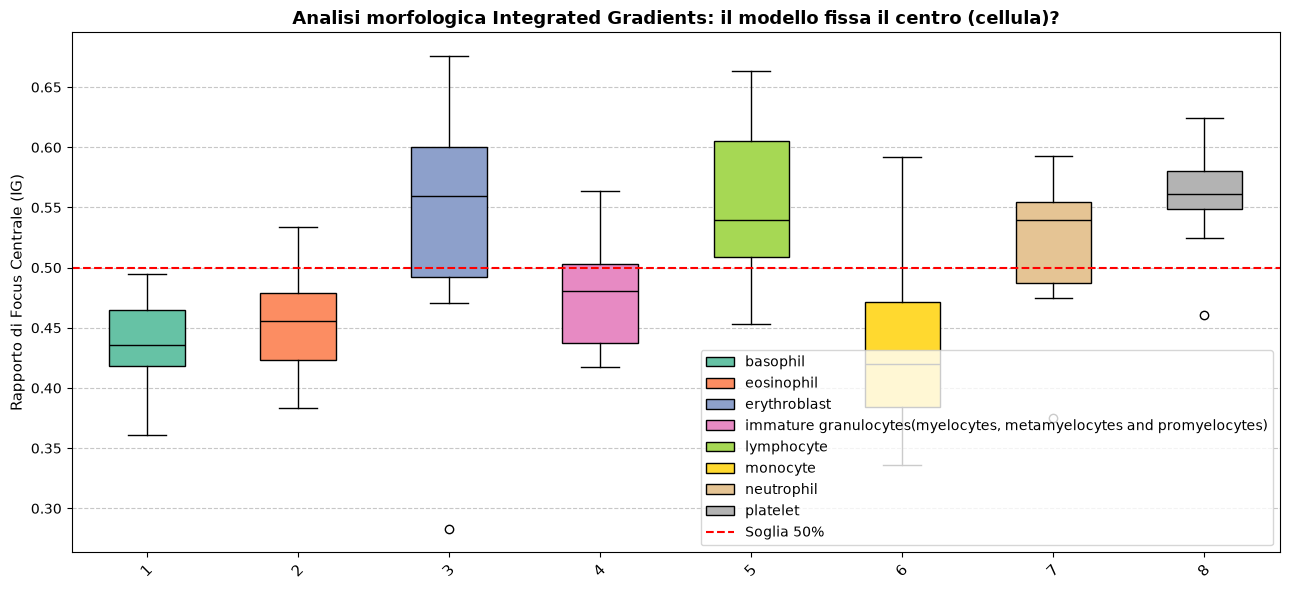

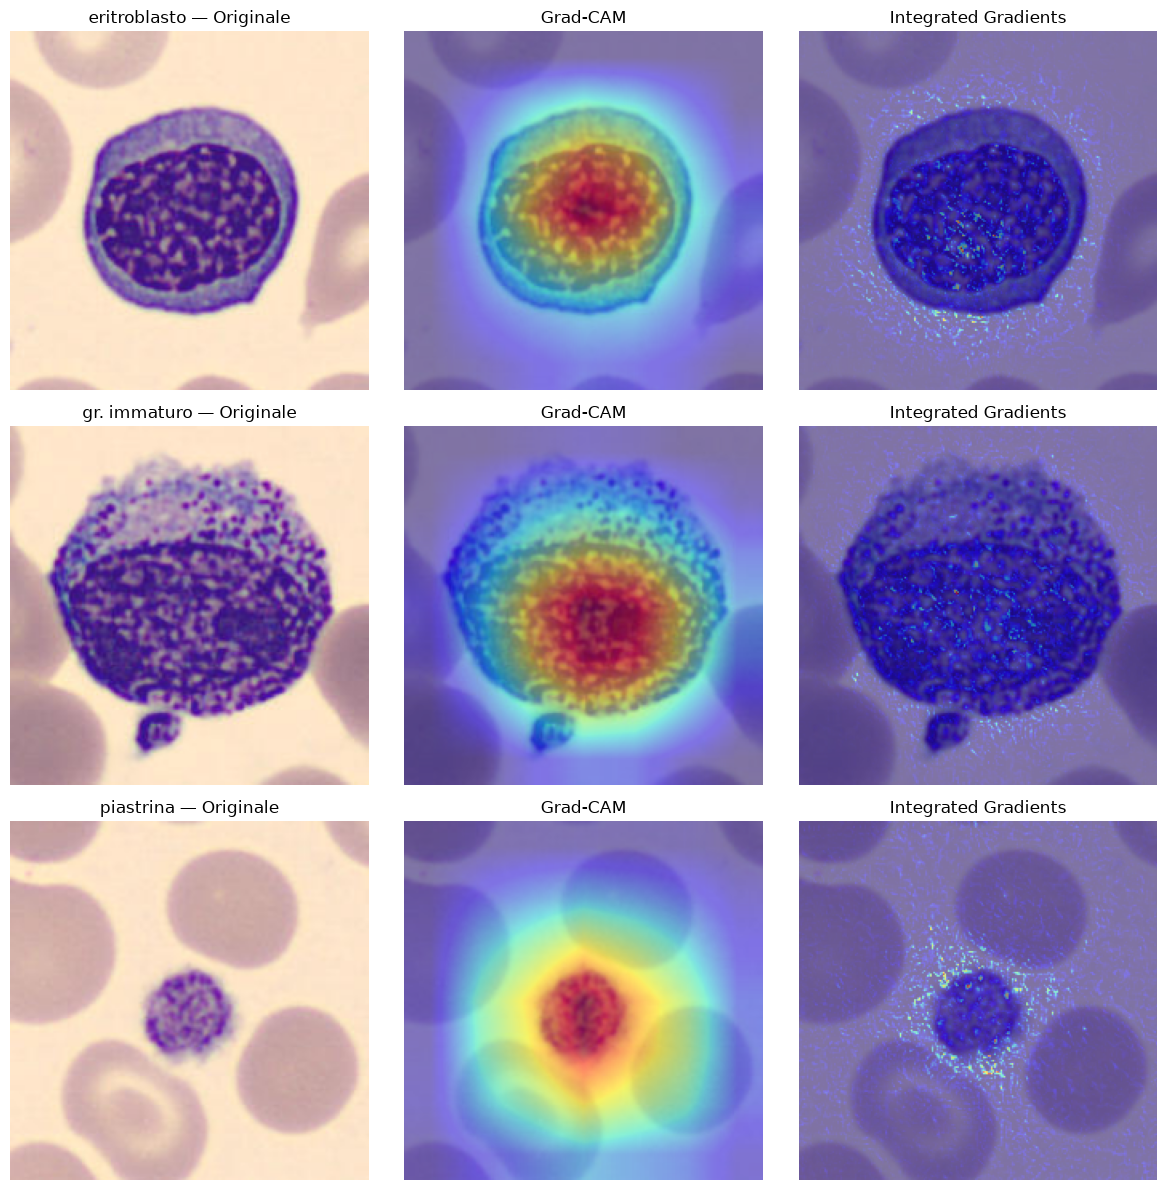


Confronto IG vs Grad-CAM completato: entrambe le mappe salvate in ../Immagini


In [21]:
def integrated_gradients(model, input_tensor, target_class, baseline=None, steps=50):
    model.eval()

    if baseline is None:
        baseline = torch.zeros_like(input_tensor)

    # Interpolazione lineare tra baseline e input reale
    alphas = torch.linspace(0, 1, steps + 1, device=input_tensor.device)
    grads = []

    for alpha in alphas:
        scaled_input = (baseline + alpha * (input_tensor - baseline)).clone().detach()
        scaled_input.requires_grad_(True)

        output = model(scaled_input)
        model.zero_grad()
        output[0, target_class].backward()

        if scaled_input.grad is None:
            raise RuntimeError("Gradiente non calcolato: verifica che il grafo computazionale sia intatto.")

        grads.append(scaled_input.grad.detach())

    grads = torch.stack(grads)                      # (steps+1, 1, C, H, W)
    avg_grads = (grads[:-1] + grads[1:]) / 2.0       # regola del trapezio
    avg_grads = avg_grads.mean(dim=0)                # (1, C, H, W)

    integrated_grad = (input_tensor - baseline) * avg_grads
    return integrated_grad.squeeze(0).detach().cpu().numpy()  # (C, H, W)


def ig_to_heatmap(ig_attr, positive_only=True):
    # Converte l'attribuzione a 3 canali (C,H,W) in una heatmap 2D normalizzata [0,1]. 
    # Con positive_only=True si isolano solo i contributi che spingono verso la classe predetta.
    if positive_only:
        ig_attr = np.clip(ig_attr, a_min=0, a_max=None)
    else:
        ig_attr = np.abs(ig_attr)

    heatmap = ig_attr.sum(axis=0)  # somma sui canali RGB
    h_min, h_max = heatmap.min(), heatmap.max()
    heatmap = (heatmap - h_min) / (h_max - h_min + 1e-8)
    return heatmap


def ig_center_ratio(heatmap: np.ndarray, center_frac: float = 0.5) -> float:
    # Stessa metrica usata per Grad-CAM, per rendere i risultati direttamente confrontabili
    h, w = heatmap.shape
    ch = int(h * (1 - center_frac) / 2)
    cw = int(w * (1 - center_frac) / 2)
    center_region = heatmap[ch:h - ch, cw:w - cw]
    return float(center_region.sum() / (heatmap.sum() + 1e-8))


# Esecuzione dell'analisi IG sugli stessi campioni usati per Grad-CAM
IG_STEPS = 50
ig_center_ratios = {name: [] for name in CLASS_NAMES}
counts_cls_ig = {i: 0 for i in range(len(CLASS_NAMES))}
n_samples_per_class_ig = 20  # Stesso numero usato per Grad-CAM

print("\nAvvio dell'analisi Integrated Gradients")

for img_raw, label in vis_dataset_norm:
    cls_idx = int(label.item() if hasattr(label, 'item') else label[0])

    if counts_cls_ig[cls_idx] >= n_samples_per_class_ig:
        continue

    img_norm = transform_test(transforms.ToPILImage()(img_raw))
    inp = img_norm.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(inp).argmax(dim=1).item()

    if pred == cls_idx:
        ig_attr = integrated_gradients(model, inp, target_class=cls_idx, steps=IG_STEPS)
        heatmap = ig_to_heatmap(ig_attr, positive_only=True)
        ratio = ig_center_ratio(heatmap)
        ig_center_ratios[CLASS_NAMES[cls_idx]].append(ratio)
        counts_cls_ig[cls_idx] += 1

    if all(v >= n_samples_per_class_ig for v in counts_cls_ig.values()):
        print("Raccolti campioni sufficienti per tutte le classi (IG).")
        break

# Boxplot comparativo IG (stessa struttura del boxplot Grad-CAM)
fig, ax = plt.subplots(figsize=(13, 6))
data_plot_ig = [ig_center_ratios[name] for name in CLASS_NAMES]
bp = ax.boxplot(data_plot_ig, label=CLASS_NAMES, patch_artist=True, medianprops={'color': 'black'})

for patch, color in zip(bp['boxes'], safe_set2_colors):
    patch.set_facecolor(color)

ax.axhline(y=0.5, color='red', linestyle='--', lw=1.5, label='Soglia 50%')
ax.set_title('Analisi morfologica Integrated Gradients: il modello fissa il centro (cellula)?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Rapporto di Focus Centrale (IG)', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'ig_morphology_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


# Confronto visivo diretto Grad-CAM vs Integrated Gradients
# Immagine originale | Overlay Grad-CAM | Overlay IG

def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()

sample_classes = list(THAL_CLASSES.keys())
fig, axes = plt.subplots(len(sample_classes), 3, figsize=(12, 4 * len(sample_classes)))

for row, cls_idx in enumerate(sample_classes):
    # Trova un campione della classe corretto correttamente classificato
    for img_raw, label in vis_dataset_norm:
        lbl = int(label.item() if hasattr(label, 'item') else label[0])
        if lbl != cls_idx:
            continue
        img_norm = transform_test(transforms.ToPILImage()(img_raw))
        inp = img_norm.unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            pred = model(inp).argmax(dim=1).item()
        if pred == cls_idx:
            break
    else:
        raise RuntimeError(f"Nessun campione correttamente classificato trovato per la classe {cls_idx}.")

    cam, _ = gradcam.generate(inp.clone(), target_class=cls_idx, size=(img_size, img_size))
    ig_attr = integrated_gradients(model, inp.clone(), target_class=cls_idx, steps=IG_STEPS)
    ig_heat = ig_to_heatmap(ig_attr, positive_only=True)

    orig_img = denormalize(img_norm)

    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title(f'{THAL_CLASSES[cls_idx]} — Originale')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(orig_img)
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Grad-CAM')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(orig_img)
    axes[row, 2].imshow(ig_heat, cmap='jet', alpha=0.5)
    axes[row, 2].set_title('Integrated Gradients')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'gradcam_vs_ig_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nConfronto IG vs Grad-CAM completato: entrambe le mappe salvate in', IMAGES_DIR)

In [ ]:
# Riepilogo Finale
print('         Riepilogo progetto BloodMNIST')
print(f'Modello:           ResNet-18 con Adversarial Fine-Tuning')
print(f'Accuratezza test pulita:  {clean_acc*100:.2f}%')
print(f'\nRobustezza avversariale')
print(f'{"ε":>6} | {"FGSM":>8} | {"PGD (10 step)":>14}')
for eps, fa, pa in zip(epsilons, fgsm_acc, pgd_acc):
    print(f'{eps:6.2f} | {fa*100:7.2f}% | {pa*100:13.2f}%')


         Riepilogo progetto BloodMNIST
Modello:           ResNet-18 con Adversarial Fine-Tuning
Accuratezza test pulita:  93.63%

--- Robustezza avversariale ---
     ε |     FGSM |  PGD (10 step)
-----------------------------------
  0.00 |   93.63% |         93.63%
  0.01 |   87.66% |         85.79%
  0.02 |   84.01% |         76.82%
  0.05 |   75.83% |         50.13%
  0.10 |   68.69% |         11.49%
  0.20 |   58.99% |          0.79%
